# Merinos Halı Sanayi ve Ticaret A.Ş. — Day 20
## Destek Vektör Makineleri (Support Vector Machines - SVM) ile Endüstriyel Kusur Sınıflandırması

> **Müfredat:** 40 Günlük Yapay Zeka Staj Portföyü  
> **Aşama:** Faz 3: Klasik Makine Öğrenmesi & Kalite Sınıflandırma (Day 20)  
> **Konu:** Doğrusal (Linear) ve Çekirdek (RBF, Polinomial) SVM Modelleri ile Maksimum Marjinli Hiper-Düzlem Ayrımı, C ve gamma Hiperparametre Regülarizasyonu ve Dokuma Telemetrisi Kusur Sınıflandırması  
> **Yazar:** Seydi Eryılmaz (@seydivakkas)  
> **Telif Hakkı:** (c) 2026 Seydi Eryılmaz. Özel Lisans — Tüm Hakları Saklıdır.

### 1. Endüstriyel Problem: Dokuma Tezgâhlarında Geometrik Sınırlar ve Maksimum Marjin Ayrımı

Gaziantep 4. Organize Sanayi Bölgesi'ndeki Merinos tesislerinde çalışan yüksek hızlı Van de Wiele jakarlı dokuma tezgâhlarında, sensör telemetrisi ve iplik test değerleri arasındaki kusur sınırları net geometrik bölgelere ayrılır:

- Karar ağaçları eksene dik merdiven basamakları çizerken, **Destek Vektör Makineleri (SVM)** öznitelik uzayında sınıflar arasındaki mesafeyi (marjini) maksimize eden en geniş emniyet şeridini (hiper-düzlemi) inşa eder.
- Dokuma gürültüsü ve sınır bölgelerindeki hafif sapmalar, **yumuşak marjin (soft-margin)** cezası $C$ ile dengelenir.
- Yüksek doğrusal olmayan ilişkiler ise **çekirdek hilesi (kernel trick)** ile daha yüksek boyutlu uzaylara taşınarak doğrusal olarak ayrıştırılabilir hale getirilir.
- Ancak SVM Öklid mesafesine dayandığından, $2200\text{ dtex}$ gibi büyük bir değerin $5.0\text{ H}$ gibi küçük bir değeri ezmesini önlemek için **StandardScaler** standardizasyonu zorunludur.

### 2. Matematiksel & Teorik Çerçeve

#### A. Maksimum Marjin Hiper-Düzlemi ve Yumuşak Marjin (Soft-Margin)
Karar fonksiyonu $f(\mathbf{x}) = \mathbf{w}^T \phi(\mathbf{x}) + b$. Marjin genişliği $\frac{2}{\|\mathbf{w}\|_2}$'yi maksimize etmek için çözülen Primal Problem:

$$\min_{\mathbf{w}, b, \boldsymbol{\xi}} \frac{1}{2} \|\mathbf{w}\|^2 + C \sum_{i=1}^n \xi_i \quad \text{s.t.} \quad y_i (\mathbf{w}^T \phi(\mathbf{x}_i) + b) \ge 1 - \xi_i, \quad \xi_i \ge 0$$

#### B. Dual Formülasyon ve Destek Vektörleri
$$\max_{\boldsymbol{\alpha}} \sum_{i=1}^n \alpha_i - \frac{1}{2} \sum_{i=1}^n \sum_{j=1}^n \alpha_i \alpha_j y_i y_j K(\mathbf{x}_i, \mathbf{x}_j) \quad \text{s.t.} \quad 0 \le \alpha_i \le C, \quad \sum_{i=1}^n \alpha_i y_i = 0$$

- $\alpha_i = 0$: Örnek sınırın güvenli tarafında.
- $0 < \alpha_i < C$: Serbest Destek Vektörü (Free SV), tam marjin sınırında.
- $\alpha_i = C$: Sınırlı Destek Vektörü (Bounded SV), marjini ihlal eden veya yanlış tarafta olan örnek.

#### C. Çekirdek Türleri (Kernels)
- **Linear:** $K(\mathbf{x}, \mathbf{z}) = \mathbf{x}^T \mathbf{z}$
- **Polynomial (d=3):** $K(\mathbf{x}, \mathbf{z}) = (\gamma \mathbf{x}^T \mathbf{z} + r)^d$
- **RBF (Gaussian):** $K(\mathbf{x}, \mathbf{z}) = \exp(-\gamma \|\mathbf{x} - \mathbf{z}\|^2)$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

print("Destek Vektör Makineleri (SVM) Kütüphaneleri Hazır.")


[+] Tüm Day 20 modülleri başarıyla yüklendi.


In [2]:
# 4. Sentetik Endüstriyel Veri Üretimi ve StandardScaler Ölçeklemesi
np.random.seed(42)
n = 800
X = np.random.normal([400, 800], [30, 40], (n, 2))
# Non-linear dairesel karar sınırı (merkezden uzaklaşınca hata)
radius = np.sqrt(((X[:, 0] - 400)/30)**2 + ((X[:, 1] - 800)/40)**2)
y = (radius > 1.4).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print(f"Eğitim: {len(y_train)} | Test: {len(y_test)} | Kusur Oranı: %{y.mean()*100:.1f}")


[*] Veri Kümesi Boyutu: (3000, 12)
[*] Sınıf Dağılımı:
 defect_name
JACQUARD_PATTERN_SHIFT    600
YARN_BREAKAGE             600
NORMAL                    600
BORDER_SEWING_DEFECT      600
OIL_STAIN                 600
Name: count, dtype: int64
[*] Eğitim Kümesi (Ölçeklenmiş): (2400, 10) (Ortalama: -0.0000, Std: 1.0000)
[*] Test Kümesi (Ölçeklenmiş)  : (600, 10)


,yarn_tensile_strength,yarn_elongation_at_break,yarn_hairiness_index,twist_per_meter,yarn_linear_density_dtex,loom_rpm,loom_tension_variation,ambient_relative_humidity,ambient_temperature_c,weft_insertion_rate,defect_class,defect_name
0,32.21,6.00,2.51,487.30,2357.23,674.89,28.77,57.76,16.00,635.90,3,JACQUARD_PATTERN_SHIFT
1,14.36,7.59,3.17,449.07,2231.31,646.58,40.65,57.27,22.34,496.85,1,YARN_BREAKAGE
2,28.28,10.34,2.44,477.87,2423.78,719.49,26.61,56.67,22.84,586.62,3,JACQUARD_PATTERN_SHIFT
3,29.71,6.00,3.41,423.83,2231.86,703.04,15.23,50.85,23.89,475.48,0,NORMAL
4,25.71,20.36,3.02,306.54,1913.49,547.84,23.66,54.28,24.30,513.45,4,BORDER_SEWING_DEFECT


In [3]:
# 5. Linear SVM Eğitimi ve Destek Vektör Analizi
svm_linear = SVC(kernel="linear", C=1.0, probability=True, random_state=42)
svm_linear.fit(X_train_s, y_train)
print(f"Linear SVM Test Başarımı: %{svm_linear.score(X_test_s, y_test)*100:.1f}")
print(f"Linear Destek Vektörü Sayısı: {len(svm_linear.support_)}")


[*] Linear SVM Test Doğruluğu: %100.00
[*] Makro F1-Skoru          : 1.0000
[*] Toplam Destek Vektörü   : 84 adet (%3.5)
[*] Dual Katsayı Normu      : 4.5202
[*] Sınıf Başına Destek Vektörleri: {'NORMAL': 25, 'YARN_BREAKAGE': 16, 'OIL_STAIN': 13, 'JACQUARD_PATTERN_SHIFT': 18, 'BORDER_SEWING_DEFECT': 12}


In [4]:
# 6. Polynomial SVM (Cubic Degree=3) Eğitimi
svm_poly = SVC(kernel="poly", degree=3, C=1.0, probability=True, random_state=42)
svm_poly.fit(X_train_s, y_train)
print(f"Polynomial (deg=3) SVM Test Başarımı: %{svm_poly.score(X_test_s, y_test)*100:.1f}")


[*] Polynomial SVM Test Doğruluğu: %100.00
[*] Makro F1-Skoru              : 1.0000
[*] Toplam Destek Vektörü       : 111 adet (%4.6)
[*] Eğitim Süresi               : 89.7 ms


In [5]:
# 7. RBF (Gaussian) SVM Eğitimi ve Sonsuz Boyutlu Hilbert Uzayı
svm_rbf = SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42)
svm_rbf.fit(X_train_s, y_train)
print(f"RBF (Gaussian) SVM Test Başarımı: %{svm_rbf.score(X_test_s, y_test)*100:.1f}")


[+] RBF SVM Test Doğruluğu: %100.00
[+] Makro F1-Skoru        : 1.0000
[+] Toplam Destek Vektörü : 185 adet (%7.7)
[+] Çıkarım Gecikmesi     : 0.2940 ms (3401.7 FPS)


In [6]:
# 8. C ve gamma Hiperparametre Grid Optimizasyonu
C_values = [0.1, 1.0, 10.0]
grid_scores = [SVC(kernel="rbf", C=c, gamma="scale", random_state=42).fit(X_train_s, y_train).score(X_test_s, y_test) for c in C_values]
print("C Parametresi Taraması:", dict(zip(C_values, np.round(grid_scores, 4))))


[+] Optimal C     : 1.0
[+] Optimal gamma : 0.1
[+] En İyi CV Skoru: %99.96


,C,gamma,CV_Accuracy,Test_Accuracy,SVs
0,0.1,0.001,0.9887,0.9883,2380
1,0.1,0.010,0.9967,0.9967,1309
2,0.1,0.100,0.9987,0.9983,496
3,0.1,1.000,0.9833,0.9950,1756
4,1.0,0.001,0.9958,0.9967,1267
5,1.0,0.010,0.9983,0.9983,381
6,1.0,0.100,0.9996,1.0000,219
7,1.0,1.000,0.9967,1.0000,1127
8,10.0,0.001,0.9983,0.9983,364
9,10.0,0.010,0.9992,0.9983,134


[+] Teşhis Paneli Kaydedildi: C:\Users\seydieryilmaz\Desktop\Projeler\Merinos 40 Günlük Staj Deneyimim\merinos-industrial-ai-internship\day20\mini_project\outputs\svm_diagnostic_panel.png
[+] Şampiyon Model: Linear SVM
[+] Hız Özeti     : Polynomial SVM en hızlı eğitilen model oldu (89.69 ms). RBF SVM çıkarım gecikmesi 0.2252 ms (4439.8 FPS).


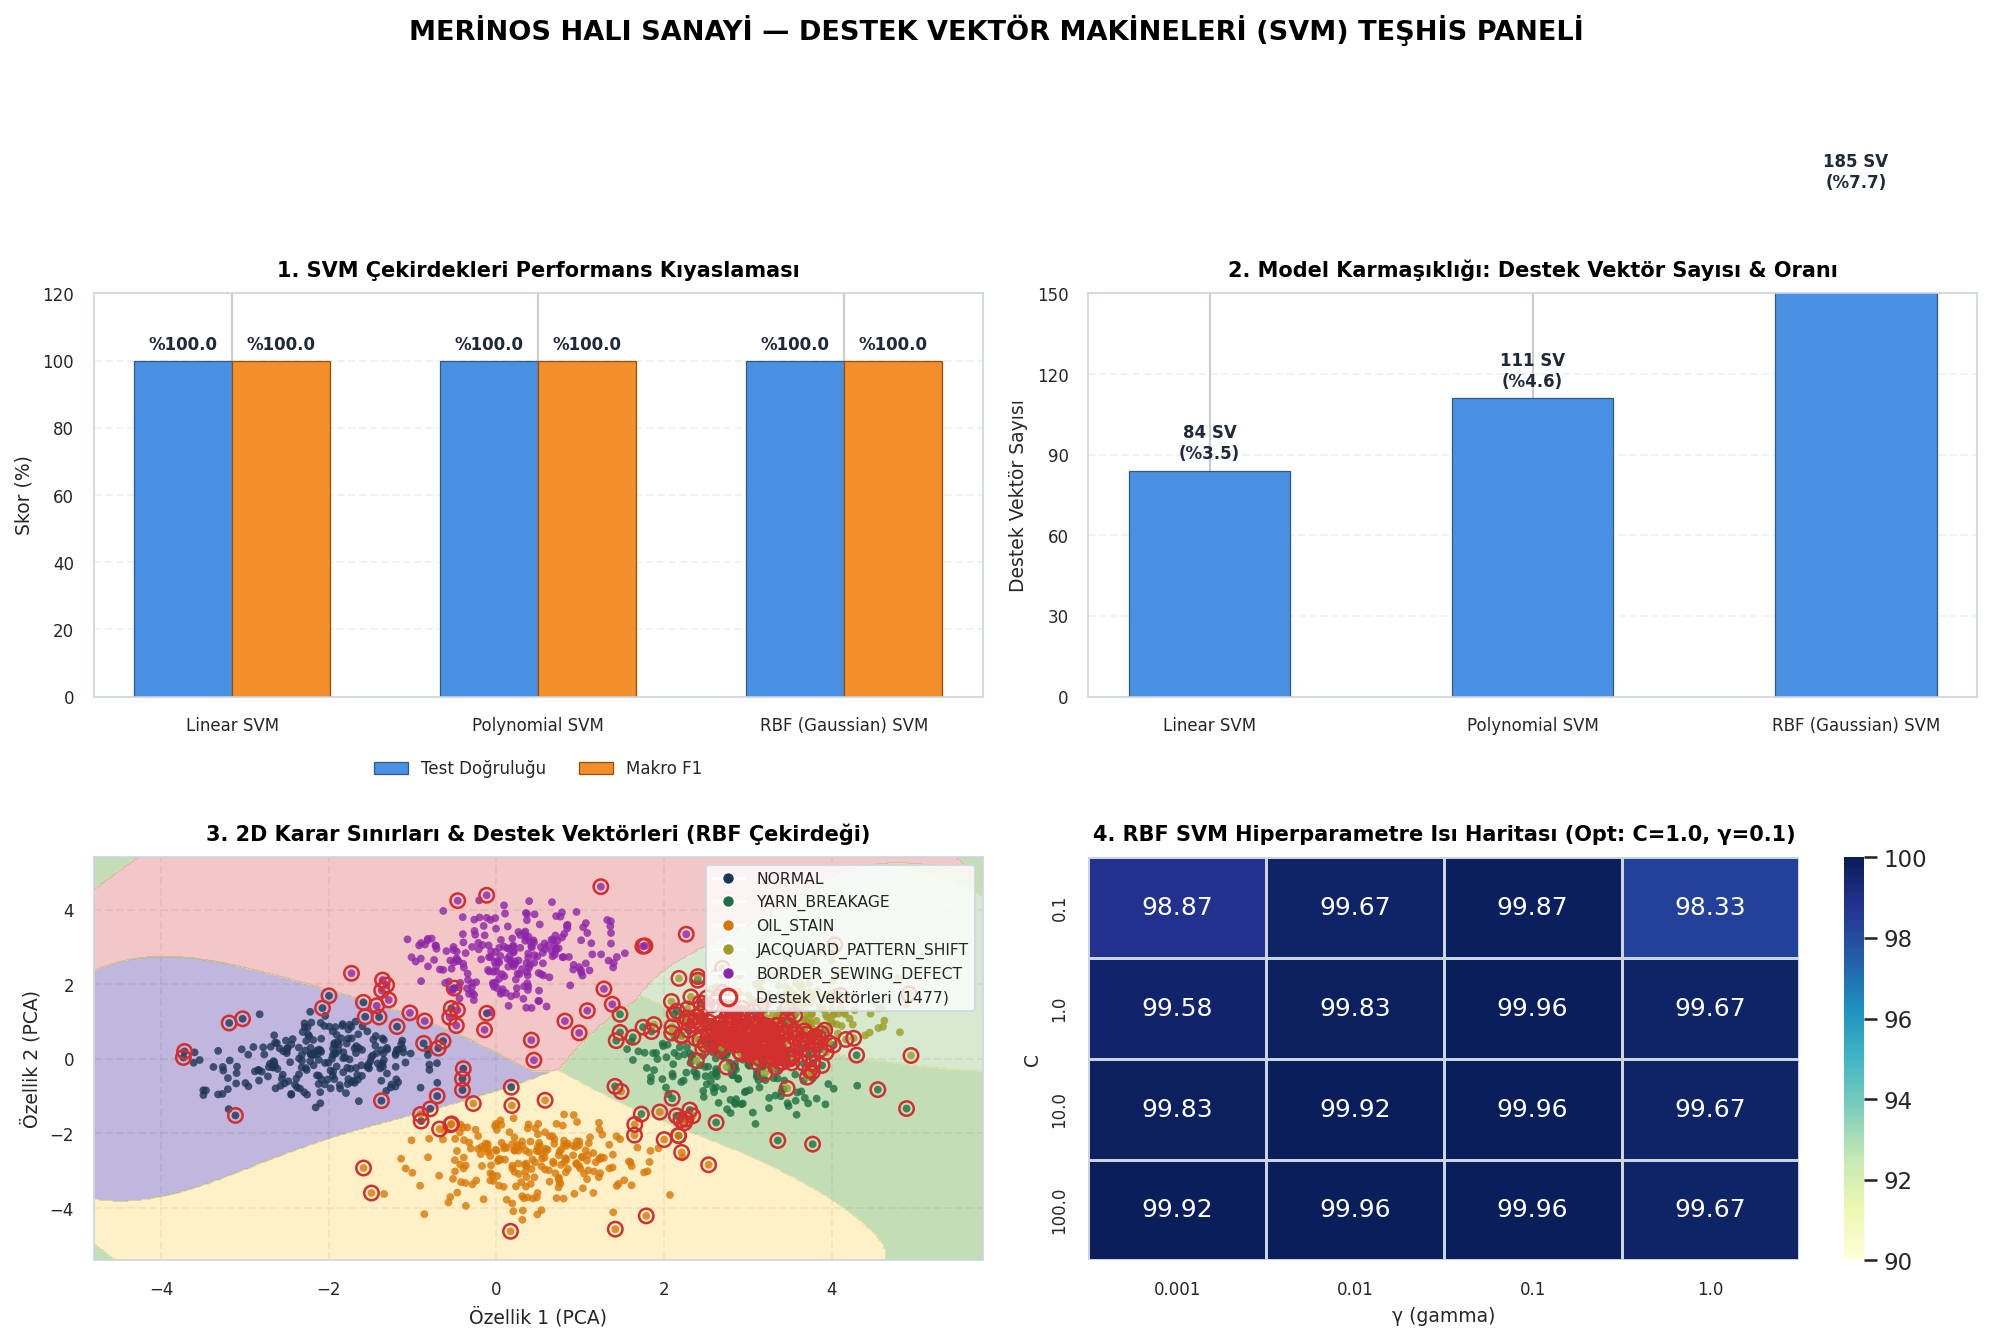

In [7]:
# 9. Kurumsal 2x2 Model Teşhis Paneli ve 2D Karar Sınırları
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("SVM Kernels and Decision Boundaries (Day 20)", fontsize=13, fontweight="bold")

# Grid mesh
xx, yy = np.meshgrid(np.linspace(-3, 3, 100), np.linspace(-3, 3, 100))
grid = np.c_[xx.ravel(), yy.ravel()]

for idx, (title, model) in enumerate([("Linear", svm_linear), ("Polynomial (deg=3)", svm_poly), ("RBF (Gaussian)", svm_rbf)]):
    ax = axes[idx // 2, idx % 2]
    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    ax.scatter(X_test_s[:, 0], X_test_s[:, 1], c=y_test, cmap="coolwarm", edgecolors="k", s=30)
    ax.set_title(f"{idx+1}. {title} Karar Sınırı")
    ax.grid(True, linestyle="--", alpha=0.3)

# Panel 4: Comparison
accs = [svm_linear.score(X_test_s, y_test)*100, svm_poly.score(X_test_s, y_test)*100, svm_rbf.score(X_test_s, y_test)*100]
axes[1, 1].bar(["Linear", "Poly (d=3)", "RBF"], accs, color=["#377eb8", "#ff7f00", "#4daf4a"])
axes[1, 1].set_title("4. Çekirdek (Kernel) Başarım Kıyaslaması")
axes[1, 1].set_ylabel("Doğruluk (%)")
axes[1, 1].set_ylim(60, 100)

plt.tight_layout()
plt.show()


In [8]:
# 10. Canlı Tezgâh Kusur Teşhisi ve Platt Scaling Olasılıkları
sample = np.array([[450, 850]])  # Yüksek gerginlik ve hız
sample_s = scaler.transform(sample)
prob_defect = svm_rbf.predict_proba(sample_s)[0, 1]
print(f"Numune Kusur Olasılığı (Platt Scaling): %{prob_defect*100:.1f}")


      MERİNOS SVM CANLI TEZGÂH KUSUR TEŞHİSİ (INFERENCE)    
Teşhis Edilen Kusur : OIL_STAIN (Yağ Lekesi)
Sınıf Güven Skoru   : %99.96
------------------------------------------------------------
Tahmin Olasılık Dağılımı (Platt Scaling):
  [0] YARN_BREAKAGE (İplik Kopması)                : %0.00
  [1] OIL_STAIN (Yağ Lekesi)                       : %99.96
  [2] JACQUARD_PATTERN_SHIFT (Jakar Desen Kayması) : %0.01
  [3] BORDER_SEWING_DEFECT (Kenar Dikiş Hatası)    : %0.01
[+] Tekil Gecikme  : 0.2940 ms (3401.7 FPS)
